# Fase 4 - Segmentación de clientes

**Entrada:** `data/clean/pedidos.csv`. **Salida:** `data/clean/clientes.csv` (una fila por cliente).

Tres técnicas, de la más simple a la más compleja:
1. **RFM**: reglas de negocio sobre recencia, frecuencia y gasto.
2. **Cohortes**: de los clientes que llegan cada mes, cuántos vuelven después.
3. **K-means**: un algoritmo agrupa a los clientes por parecido, sin reglas previas.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

pedidos = pd.read_csv("../data/clean/pedidos.csv", parse_dates=["order_purchase_timestamp"])

AZUL = "#3b6ea5"

## 1. RFM

| Letra | Significado | Cómo se calcula |
|---|---|---|
| **R** | Recencia | Días desde la última compra (menos es mejor) |
| **F** | Frecuencia | Número de pedidos |
| **M** | Valor monetario | Gasto total |

La recencia se mide respecto a una fecha de referencia: el día siguiente al último pedido del dataset.

In [2]:
fecha_ref = pedidos["order_purchase_timestamp"].max() + pd.DateOffset(days=1)

clientes = pedidos.groupby("customer_unique_id").agg(
    ultima_compra=("order_purchase_timestamp", "max"),
    frecuencia=("order_id", "count"),
    gasto=("valor_total", "sum"),
    nota_media=("review_score", "mean"),
    dias_entrega_medio=("dias_entrega", "mean"),
    estado=("customer_state", "last"),
).reset_index()

clientes["recencia"] = (fecha_ref - clientes["ultima_compra"]).dt.days

clientes[["recencia", "frecuencia", "gasto"]].describe().round(1)

,recencia,frecuencia,gasto
count,93096.0,93096.0,93096.0
mean,236.7,1.0,165.2
std,150.9,0.2,226.4
min,1.0,1.0,9.6
25%,114.0,1.0,63.0
50%,218.0,1.0,107.8
75%,345.0,1.0,182.5
max,602.0,15.0,13664.1


### Puntuaciones
Lo habitual es puntuar cada variable de 1 a 5 por quintiles (`pd.qcut` parte en grupos del mismo tamaño).

**Problema:** el 97 % de los clientes tiene frecuencia 1, así que no se pueden hacer cinco grupos de frecuencia.
Solución: R y M por quintiles; la frecuencia se usa tal cual (1 pedido o 2 o más).

In [3]:
# Recencia: 5 = compró hace poco. Por eso las etiquetas van al revés.
clientes["R"] = pd.qcut(clientes["recencia"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
clientes["M"] = pd.qcut(clientes["gasto"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

clientes.groupby("R")["recencia"].agg(["min", "max"]).join(
    clientes.groupby("M")["gasto"].agg(["min", "max"]), lsuffix="_recencia", rsuffix="_gasto")

,min_recencia,max_recencia,min_gasto,max_gasto
R,,,,
1,381,602,9.59,55.24
2,269,380,55.25,87.36
3,178,268,87.37,132.60
4,93,177,132.61,208.51
5,1,92,208.52,13664.08


### Segmentos
Reglas, aplicadas en este orden:

| Segmento | Regla |
|---|---|
| Recurrentes | 2 o más pedidos |
| Alto valor reciente | 1 pedido, gasto en el 20 % superior (M = 5), compra reciente (R >= 4) |
| Alto valor inactivo | 1 pedido, M = 5, R <= 3 |
| Recientes | 1 pedido, M < 5, R >= 4 |
| Inactivos | el resto |

In [4]:
def segmento(c):
    if c["frecuencia"] >= 2:
        return "Recurrentes"
    if c["M"] == 5:
        return "Alto valor reciente" if c["R"] >= 4 else "Alto valor inactivo"
    return "Recientes" if c["R"] >= 4 else "Inactivos"

clientes["segmento"] = clientes.apply(segmento, axis=1)

rfm = clientes.groupby("segmento").agg(
    clientes=("customer_unique_id", "count"),
    recencia_media=("recencia", "mean"),
    frecuencia_media=("frecuencia", "mean"),
    gasto_medio=("gasto", "mean"),
    gasto_total=("gasto", "sum"),
    nota_media=("nota_media", "mean"),
).sort_values("gasto_total", ascending=False)

rfm["pct_clientes"] = 100 * rfm["clientes"] / rfm["clientes"].sum()
rfm["pct_ingresos"] = 100 * rfm["gasto_total"] / rfm["gasto_total"].sum()
rfm.round(1)

,clientes,recencia_media,frecuencia_media,gasto_medio,gasto_total,nota_media,pct_clientes,pct_ingresos
segmento,,,,,,,,
Alto valor inactivo,10137,338.9,1.0,435.7,4417156.7,4.0,10.9,28.7
Inactivos,43948,334.6,1.0,94.3,4144526.4,4.1,47.2,27.0
Alto valor reciente,6950,91.8,1.0,449.6,3124815.3,4.1,7.5,20.3
Recientes,29272,90.4,1.0,96.6,2828632.2,4.2,31.4,18.4
Recurrentes,2789,219.6,2.1,308.8,861300.4,4.2,3.0,5.6


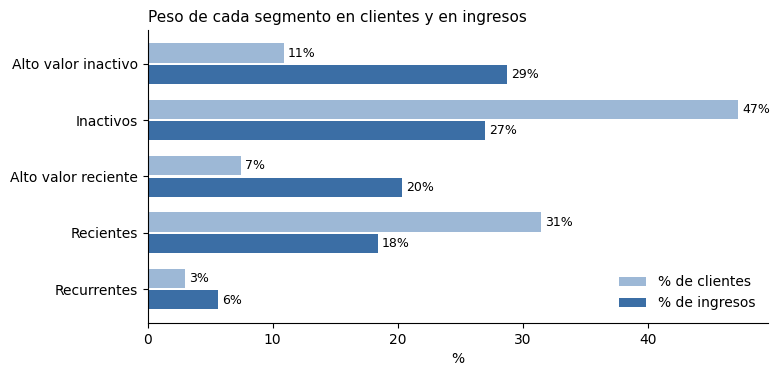

In [5]:
orden = rfm.sort_values("pct_ingresos").index
y = np.arange(len(orden))

fig, eje = plt.subplots(figsize=(8, 3.8))
b1 = eje.barh(y + 0.19, rfm.loc[orden, "pct_clientes"], height=0.34, color="#9db8d6", label="% de clientes")
b2 = eje.barh(y - 0.19, rfm.loc[orden, "pct_ingresos"], height=0.34, color=AZUL, label="% de ingresos")
eje.bar_label(b1, fmt="%.0f%%", padding=3, fontsize=9)
eje.bar_label(b2, fmt="%.0f%%", padding=3, fontsize=9)
eje.set_yticks(y, orden)
eje.set_xlabel("%")
eje.legend(frameon=False, loc="lower right")
eje.set_title("Peso de cada segmento en clientes y en ingresos", loc="left", fontsize=11)
eje.spines[["top", "right"]].set_visible(False)
plt.show()

## 2. Análisis de cohortes

Una **cohorte** es el grupo de clientes que hizo su primera compra en el mismo mes.
Para cada cohorte medimos qué porcentaje vuelve a comprar 1, 2, 3... meses después.

In [6]:
pedidos["mes_pedido"] = pedidos["order_purchase_timestamp"].dt.to_period("M")
# transform("min") devuelve, para cada pedido, el primer mes de compra de su cliente
pedidos["cohorte"] = pedidos.groupby("customer_unique_id")["mes_pedido"].transform("min")

# Meses transcurridos entre la primera compra y este pedido
pedidos["n_mes"] = ((pedidos["mes_pedido"].dt.year - pedidos["cohorte"].dt.year) * 12
                    + (pedidos["mes_pedido"].dt.month - pedidos["cohorte"].dt.month))

# Tabla: filas = cohorte, columnas = mes transcurrido, valor = clientes distintos
cohortes = (pedidos.groupby(["cohorte", "n_mes"])["customer_unique_id"]
            .nunique().unstack())

tamano = cohortes[0]                                    # clientes que entraron en cada cohorte
retencion = cohortes.div(tamano, axis=0) * 100          # en porcentaje
retencion.iloc[:, 1:13].round(2).head(8)

n_mes,1,2,3,4,5,6,7,8,9,10,11,12
cohorte,,,,,,,,,,,,
2017-01,0.28,0.28,0.14,0.42,0.14,0.42,0.14,0.14,NaN,0.42,0.14,0.70
2017-02,0.18,0.31,0.12,0.43,0.12,0.25,0.18,0.12,0.18,0.12,0.31,0.12
2017-03,0.44,0.36,0.40,0.36,0.16,0.16,0.32,0.32,0.08,0.36,0.12,0.20
2017-04,0.62,0.22,0.18,0.27,0.27,0.35,0.31,0.31,0.18,0.27,0.09,0.04
2017-05,0.46,0.46,0.29,0.29,0.32,0.41,0.14,0.26,0.26,0.26,0.35,0.23
2017-06,0.49,0.40,0.43,0.30,0.40,0.36,0.23,0.13,0.20,0.30,0.36,0.16
2017-07,0.53,0.35,0.24,0.29,0.21,0.32,0.11,0.19,0.27,0.21,0.29,0.13
2017-08,0.69,0.35,0.27,0.35,0.52,0.30,0.27,0.15,0.15,0.25,0.20,0.12


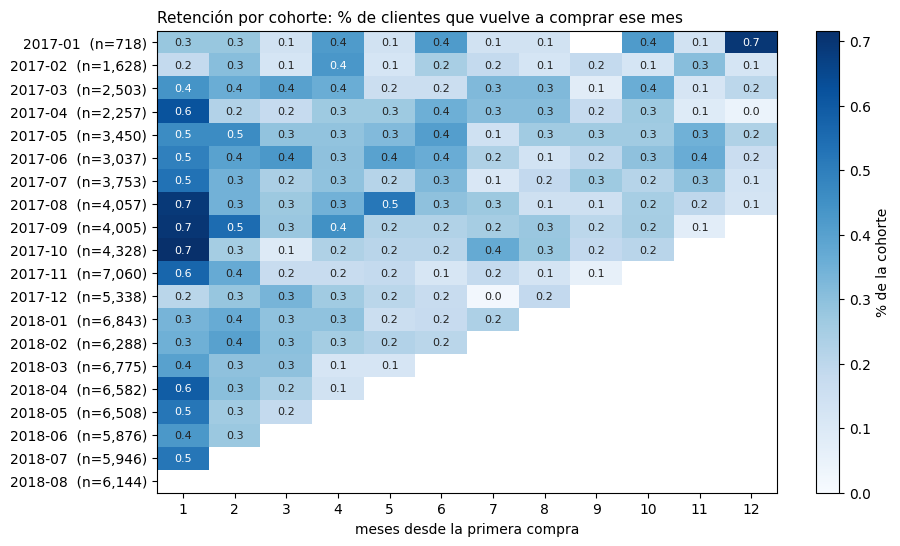

In [7]:
tabla = retencion.iloc[:, 1:13]                          # meses 1 a 12 (el mes 0 es siempre 100 %)

fig, eje = plt.subplots(figsize=(10, 6))
imagen = eje.imshow(tabla.values, cmap="Blues", aspect="auto", vmin=0, vmax=tabla.max().max())

for i in range(tabla.shape[0]):
    for j in range(tabla.shape[1]):
        v = tabla.values[i, j]
        if not np.isnan(v):
            eje.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8,
                     color="white" if v > 0.6 * tabla.max().max() else "#222222")

eje.set_xticks(range(tabla.shape[1]), tabla.columns)
eje.set_yticks(range(tabla.shape[0]), [f"{c}  (n={int(n):,})" for c, n in zip(tabla.index, tamano)])
eje.set_xlabel("meses desde la primera compra")
eje.set_title("Retención por cohorte: % de clientes que vuelve a comprar ese mes", loc="left", fontsize=11)
fig.colorbar(imagen, ax=eje, label="% de la cohorte")
plt.show()

In [8]:
# Retención media por mes transcurrido (media de las cohortes que han tenido tiempo de llegar a ese mes)
tabla.mean().round(2)

n_mes
1     0.48
2     0.34
3     0.25
4     0.29
5     0.23
6     0.26
7     0.21
8     0.21
9     0.18
10    0.26
11    0.21
12    0.21
dtype: float64

### ¿Cuándo vuelven los que vuelven?

In [9]:
orden_pedidos = pedidos.sort_values("order_purchase_timestamp")
orden_pedidos["dias_desde_anterior"] = (orden_pedidos.groupby("customer_unique_id")["order_purchase_timestamp"]
                                        .diff().dt.total_seconds() / 86400)
recompras = orden_pedidos["dias_desde_anterior"].dropna()

print(f"Recompras: {len(recompras):,}")
print(f"El mismo día:          {(recompras < 1).mean():.1%}")
print(f"En menos de 30 días:   {(recompras < 30).mean():.1%}")
print(f"En menos de 90 días:   {(recompras < 90).mean():.1%}")
print(f"Mediana:               {recompras.median():.0f} días")

Recompras: 3,107
El mismo día:          29.6%
En menos de 30 días:   50.2%
En menos de 90 días:   69.0%
Mediana:               29 días


## 3. K-means

K-means reparte a los clientes en *k* grupos de forma que los de un mismo grupo se parezcan entre sí.

Tres preparativos necesarios:
- **Elegir variables**: recencia, frecuencia, gasto, nota media y plazo medio de entrega.
- **Logaritmo del gasto**: el gasto tiene valores extremos muy altos; el logaritmo los comprime.
- **Estandarizar**: K-means mide distancias. Sin poner todas las variables en la misma escala,
  la recencia (0 a 600) pesaría mucho más que la nota (1 a 5).

In [10]:
variables = ["recencia", "frecuencia", "log_gasto", "nota_media", "dias_entrega_medio"]

clientes["log_gasto"] = np.log(clientes["gasto"])
datos = clientes.dropna(subset=["nota_media"]).copy()        # K-means no admite nulos
print(f"Clientes sin ninguna valoración, fuera del clustering: {len(clientes) - len(datos):,}")

X = StandardScaler().fit_transform(datos[variables])

Clientes sin ninguna valoración, fuera del clustering: 600


### ¿Cuántos grupos?
- **Inercia** (método del codo): suma de distancias al centro de cada grupo. Siempre baja al añadir grupos; se busca dónde deja de bajar deprisa.
- **Silueta**: de -1 a 1, mide lo bien separados que están los grupos. Más alto es mejor. Se calcula sobre una muestra de 10.000 clientes porque es lenta.

In [11]:
muestra = np.random.RandomState(42).choice(len(X), 10000, replace=False)

resultados = []
for k in range(2, 9):
    modelo = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    resultados.append({"k": k, "inercia": modelo.inertia_,
                       "silueta": silhouette_score(X[muestra], modelo.labels_[muestra])})

resultados = pd.DataFrame(resultados).set_index("k")
resultados.round(3)

,inercia,silueta
k,,
2,376325.939,0.344
3,299122.970,0.375
4,242050.772,0.265
5,209046.362,0.248
6,184961.480,0.259
7,171204.521,0.230
8,158042.632,0.246


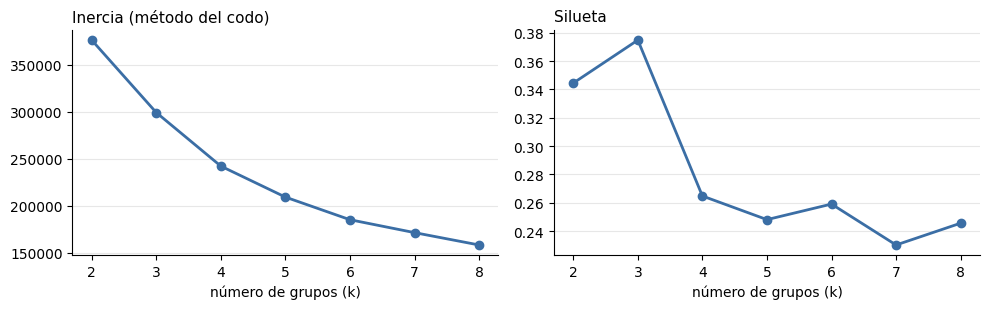

In [12]:
fig, ejes = plt.subplots(1, 2, figsize=(10, 3.2))
for eje, col, titulo in [(ejes[0], "inercia", "Inercia (método del codo)"), (ejes[1], "silueta", "Silueta")]:
    eje.plot(resultados.index, resultados[col], color=AZUL, linewidth=2, marker="o")
    eje.set_xlabel("número de grupos (k)")
    eje.set_title(titulo, loc="left", fontsize=11)
    eje.spines[["top", "right"]].set_visible(False)
    eje.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Elección de k
La silueta es máxima con **k = 3**: insatisfechos, satisfechos y recurrentes.
Con **k = 4** el grupo de satisfechos se divide en antiguos y recientes. La silueta baja (los dos grupos nuevos
se parecen entre sí), pero la división es útil: a unos hay que reactivarlos y a otros fidelizarlos.
Se elige 4 por utilidad para el negocio, sabiendo que estadísticamente 3 separa mejor.

In [13]:
K = 4
modelo = KMeans(n_clusters=K, n_init=10, random_state=42).fit(X)
datos["cluster"] = modelo.labels_

# Nombres puestos a mano después de mirar el perfil de cada grupo (tabla de abajo)
nombres = {0: "Satisfechos antiguos", 1: "Satisfechos recientes", 2: "Insatisfechos", 3: "Recurrentes"}
datos["cluster"] = datos["cluster"].map(nombres)

perfil = datos.groupby("cluster").agg(
    clientes=("customer_unique_id", "count"),
    recencia=("recencia", "mean"),
    frecuencia=("frecuencia", "mean"),
    gasto=("gasto", "mean"),
    nota_media=("nota_media", "mean"),
    dias_entrega=("dias_entrega_medio", "mean"),
    gasto_total=("gasto", "sum"),
)
perfil["pct_clientes"] = 100 * perfil["clientes"] / perfil["clientes"].sum()
perfil["pct_ingresos"] = 100 * perfil["gasto_total"] / perfil["gasto_total"].sum()
perfil.drop(columns="gasto_total").round(2)

,clientes,recencia,frecuencia,gasto,nota_media,dias_entrega,pct_clientes,pct_ingresos
cluster,,,,,,,,
Insatisfechos,14271,231.07,1.00,195.68,1.65,22.25,15.43,18.31
Recurrentes,2780,219.33,2.11,308.41,4.20,12.30,3.01,5.62
Satisfechos antiguos,33002,387.72,1.00,156.99,4.60,11.68,35.68,33.96
Satisfechos recientes,42443,121.98,1.00,151.36,4.64,9.89,45.89,42.11


## 4. Guardar

In [14]:
clientes = clientes.merge(datos[["customer_unique_id", "cluster"]], on="customer_unique_id", how="left")

clientes[["customer_unique_id", "estado", "ultima_compra", "recencia", "frecuencia", "gasto",
          "nota_media", "dias_entrega_medio", "R", "M", "segmento", "cluster"]].to_csv(
    "../data/clean/clientes.csv", index=False)

print(f"clientes.csv  {len(clientes):,} filas")

clientes.csv  93,096 filas
